In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,dem_inc_dummy,rep_inc_dummy,pvi,census_region,dem_scandal_score,rep_scandal_score,Year,Geography,dem_stand,rep_stand
0,0,2018,Alabama,AL,False,AL-01,89226.0,153228.0,242617,Robert Kennedy Jr.,...,0,1,-15.715056,East South Central,0.0,0.0,2018.0,AL-01,Robert Kennedy Jr.,Bradley Byrne
1,1,2018,Alabama,AL,False,AL-02,86931.0,138879.0,226230,Tabitha Isner,...,0,1,-16.880853,East South Central,0.0,0.0,2018.0,AL-02,Tabitha Isner,Martha Roby
2,2,2018,Alabama,AL,False,AL-03,83996.0,147770.0,231915,Mallory Hagan,...,0,1,-17.206974,East South Central,0.0,0.0,2018.0,AL-03,Mallory Hagan,Mike Rogers
3,3,2018,Alabama,AL,False,AL-04,46492.0,184255.0,230969,Lee Auman,...,0,1,-31.882701,East South Central,0.0,0.0,2018.0,AL-04,Lee Auman,Robert Aderholt
4,4,2018,Alabama,AL,False,AL-05,101388.0,159063.0,260673,Peter Joffrion,...,0,1,-18.025364,East South Central,0.0,0.0,2018.0,AL-05,Peter Joffrion,Mo Brooks


In [4]:
data['is_2020'] = data['year'].map(lambda x: 1 if x == 2020 else 0)

In [5]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2018 AL-01              0  Alabama       AL    False   89226.0  153228.0   
     AL-02              1  Alabama       AL    False   86931.0  138879.0   
     AL-03              2  Alabama       AL    False   83996.0  147770.0   
     AL-04              3  Alabama       AL    False   46492.0  184255.0   
     AL-05              4  Alabama       AL    False  101388.0  159063.0   

               totalvotes            dem_cand         rep_cand dem_inc  ...  \
year district                                                           ...   
2018 AL-01         242617  Robert Kennedy Jr.    Bradley Byrne   False  ...   
     AL-02         226230       Tabitha Isner      Martha Roby   False  ...   
     AL-03         231915       Mallory Hagan      Mike Rogers   False  ...   
     AL-04         230969           Lee Auman  Robert Aderholt   False  ...   
     AL-05         260673      Peter Joffrion        Mo Brooks   False  ...   

              rep_inc_dummy        pvi       census_region  dem_scandal_score  \
year district                                                                   
2018 AL-01                1 -15.715056  East South Central                0.0   
     AL-02                1 -16.880853  East South Central                0.0   
     AL-03                1 -17.206974  East South Central                0.0   
     AL-04                1 -31.882701  East South Central                0.0   
     AL-05                1 -18.025364  East South Central                0.0   

               rep_scandal_score    Year  Geography           dem_stand  \
year district                                                             
2018 AL-01                   0.0  2018.0      AL-01  Robert Kennedy Jr.   
     AL-02                   0.0  2018.0      AL-02       Tabitha Isner   
     AL-03                   0.0  2018.0      AL-03       Mallory Hagan   
     AL-04                   0.0  2018.0      AL-04           Lee Auman   
     AL-05                   0.0  2018.0      AL-05      Peter Joffrion   

                     rep_stand  is_2020  
year district                            
2018 AL-01       Bradley Byrne        0  
     AL-02         Martha Roby        0  
     AL-03         Mike Rogers        0  
     AL-04     Robert Aderholt        0  
     AL-05           Mo Brooks        0  

[5 rows x 62 columns]

In [6]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'generic_ballot_avg', 'pres_approval_avg',
       'incumbent_pres', 'ics', 'pres_approval_avg_x_incpres',
       'ics_x_incpres', 'cvap_pop', 'cvap_white_pct', 'cvap_aapi_pct',
       'cvap_hisp_pct', 'cvap_black_pct', 'cvap_natam_pct', 'college',
       'Code', 'area', 'density_proxy', 'demo_cluster', 'district_id',
       'density_proxy_capped', 'no_dem_cand_flag', 'no_rep_cand_flag',
       'dem_inc_any', 'rep_inc_any', 'dem_inc_dummy', 'rep_inc_dummy',
       'pvi', 'census_region', 'dem_scandal_score', 'rep_scandal_score',
       'Year', 'Geography', 'dem_stand', '

In [7]:
data['rep_tot_funds'].isna().any()

np.False_

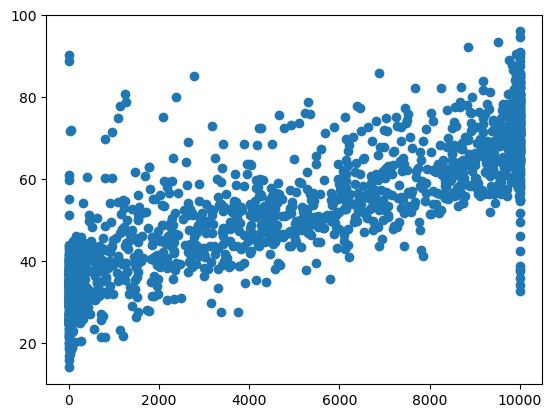

In [8]:
# plt.scatter(np.sqrt(data['dem_effn']) * (data['dem_poll_avg'] - data['rep_poll_avg']), data['dem_pct_2p'])
plt.scatter(data['dem_funds_2p_pct']**2, data['dem_pct_2p'])

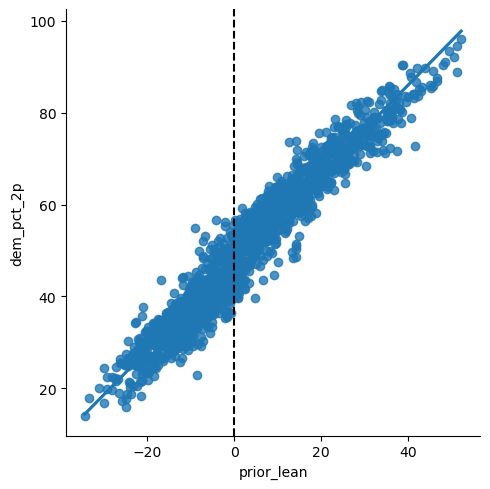

In [12]:
# plt.scatter(data['pvi'] - data['generic_ballot_avg'], data['dem_pct_2p'])
data['prior_lean'] = data['pvi'] - data['generic_ballot_avg']
sns.lmplot(
    data,
    x='prior_lean', y='dem_pct_2p'
)
plt.axvline(0, color='black', linestyle='--')

<Axes: xlabel='rep_scandal_score', ylabel='dem_pct_2p'>

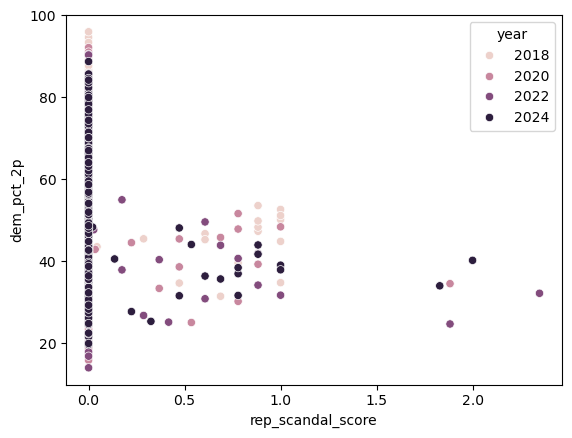

In [93]:
# sns.scatterplot(
#     data.reset_index(),
#     x='rep_scandal_score', y='dem_pct_2p', hue='year' 
# )

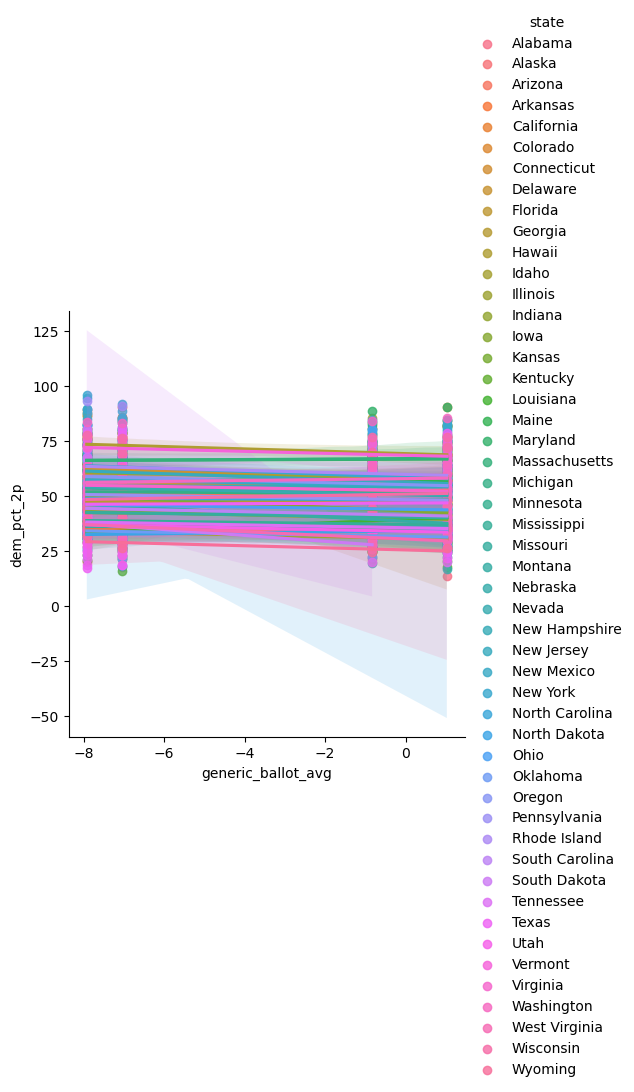

In [94]:
data_resind = data.reset_index()

sns.lmplot(
    data_resind,
    x='generic_ballot_avg', y='dem_pct_2p', hue='state'
)

In [95]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2
data['sqrt_effn'] = np.sqrt(data['dem_effn'])
data['poll_margin'] = data['dem_poll_avg'] - data['rep_poll_avg']
data['effnXmargin'] = data['sqrt_effn'] * data['poll_margin']

## Preliminary Model Check (Frequentist OLS)

In [104]:
y = data[data['is_2020'] == 0]['dem_pct_2p']
X = data[data['is_2020'] == 0][['pvi', 'generic_ballot_avg',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd',
          'is_2020']]
         # 'cvap_black_pct', 'cvap_hisp_pct', 'cvap_natam_pct', 'cvap_aapi_pct',
         #'effnXmargin',]] 
          #'college']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [105]:
X.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,is_2020
pvi,1.000000,0.058855,0.720606,-0.693608,0.800073,NaN
generic_ballot_avg,0.058855,1.000000,0.066622,-0.083130,-0.075512,NaN
dem_inc_dummy,0.720606,0.066622,1.000000,-0.710562,0.718602,NaN
rep_inc_dummy,-0.693608,-0.083130,-0.710562,1.000000,-0.704230,NaN
dem_funds_2p_pct_sqrd,0.800073,-0.075512,0.718602,-0.704230,1.000000,NaN
is_2020,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
np.linalg.matrix_rank(X)

np.int64(5)

In [107]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dem_pct_2p   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     4991.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:15:15   Log-Likelihood:                -2000.5
No. Observations:                 799   AIC:                             4013.
Df Residuals:                     793   BIC:                             4041.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    48.4400      0.406    119.452      0.000      47.645      49.235
pvi                       0.8595      0.016     55.047      0.000       0.829       0.890
generic_ballot_avg       -0.4920      0.029    -17.196      0.000      -0.548      -0.436
dem_inc_dummy             0.8019      0.388      2.066      0.039       0.041       1.563
rep_inc_dummy            -1.9970      0.355     -5.625      0.000      -2.693      -1.301
dem_funds_2p_pct_sqrd     0.0004   6.18e-05      6.847      0.000       0.000       0.001
is_2020                        0          0        nan        nan           0           0
==============================================================================
Omnibus:                       26.981   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.664
Skew:                          -0.074   Prob(JB):                     9.08e-15
Kurtosis:                       4.386   Cond. No.                          inf
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [100]:
y_test_hat = reg.predict(sm.add_constant(X_test))
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(7.164720865262237), np.float64(2.1003796647709225))

In [101]:
y_test - y_test_hat

year  district
2020  IL-15      -3.449552
2018  TX-31       2.915041
      MD-07      -1.701714
      IN-04      -1.507759
2022  IN-01       1.435345
                    ...   
2020  WA-05      -2.312104
2018  WA-04      -2.683673
2024  NC-12       1.933678
2018  IL-13       0.014055
2022  CA-02       1.749881
Length: 529, dtype: float64

In [102]:
X_test.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,is_2020,residuals
pvi,1.000000,0.028109,0.721911,-0.682265,0.800179,-0.005622,-0.055621
generic_ballot_avg,0.028109,1.000000,-0.038077,-0.004231,-0.074937,-0.503996,-0.047124
dem_inc_dummy,0.721911,-0.038077,1.000000,-0.740432,0.702962,0.120487,-0.051307
rep_inc_dummy,-0.682265,-0.004231,-0.740432,1.000000,-0.690888,-0.085198,0.011758
dem_funds_2p_pct_sqrd,0.800179,-0.074937,0.702962,-0.690888,1.000000,0.014888,-0.028639
is_2020,-0.005622,-0.503996,0.120487,-0.085198,0.014888,1.000000,0.069252
residuals,-0.055621,-0.047124,-0.051307,0.011758,-0.028639,0.069252,1.000000


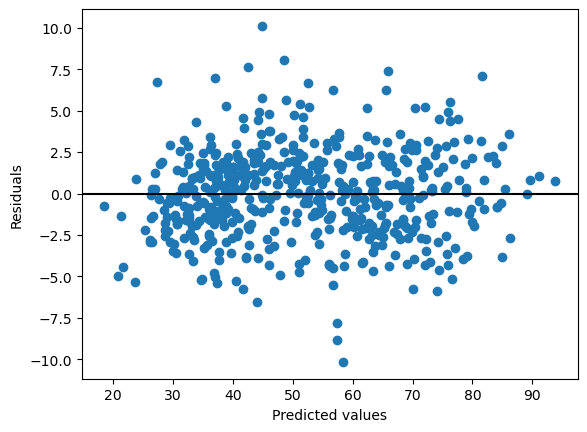

In [103]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

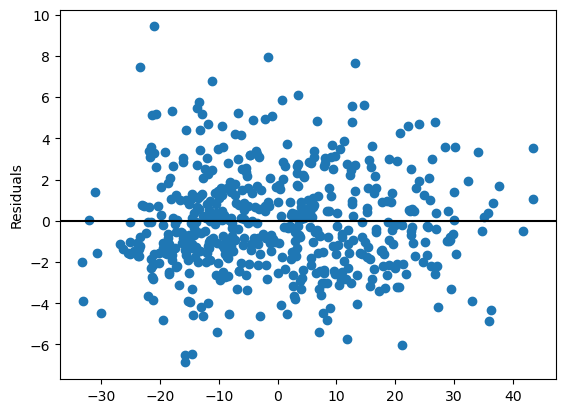

In [56]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

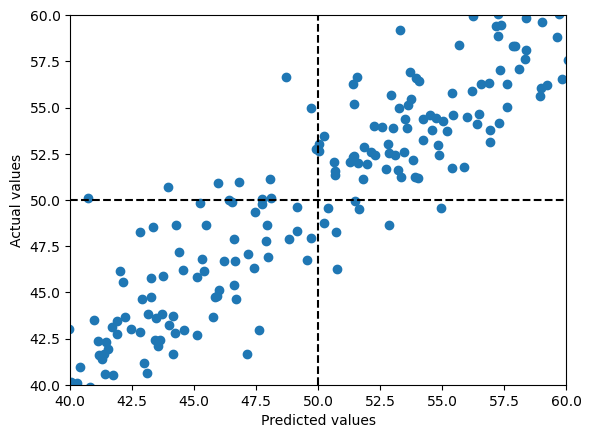

In [57]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

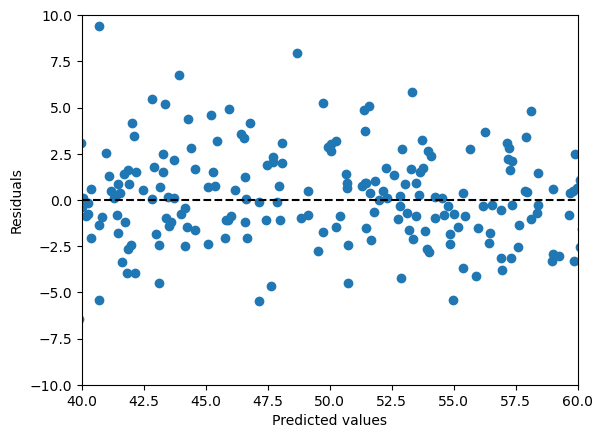

In [58]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [59]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,IL-15,1.544257
1,2018,TX-31,-5.173558
2,2018,MD-07,1.652631
3,2018,IN-04,0.361365
4,2022,IN-01,-1.011373


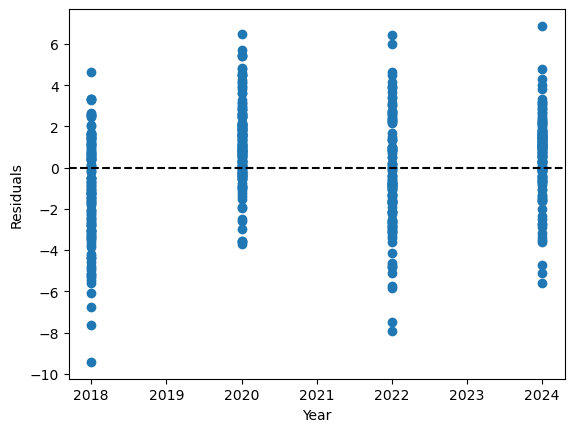

In [60]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

In [61]:
durbin_watson(reg.resid)

np.float64(1.9784027336335988)